In [7]:
import sys
sys.path.append("../src")
import numpy as np
import torch
import h5py
from tqdm import tqdm
from torch.autograd.functional import jacobian
import argparse
import itertools

from realstar_synthetic_observations import Observations
from transformer import *
from template import Template
from sbart_rv_finder import RV_Retrieval
from score_models import ScoreModel
from spectrum_lsf import Score_Likelihood
from mala import MALA


In [8]:
i =0 
snr = 50
order = 21
val_data_file = "SPIRou21_val.df"
nspec = 20

obs = Observations(i=i, seed=0, SNR=snr, filepath="../data/validation_data/"+val_data_file, N=nspec,order=order,star='barnards')
synthetic_spectra, uncertainty = obs.make_observations(func='connors', add_RV=True)

(0.0, 1.1)

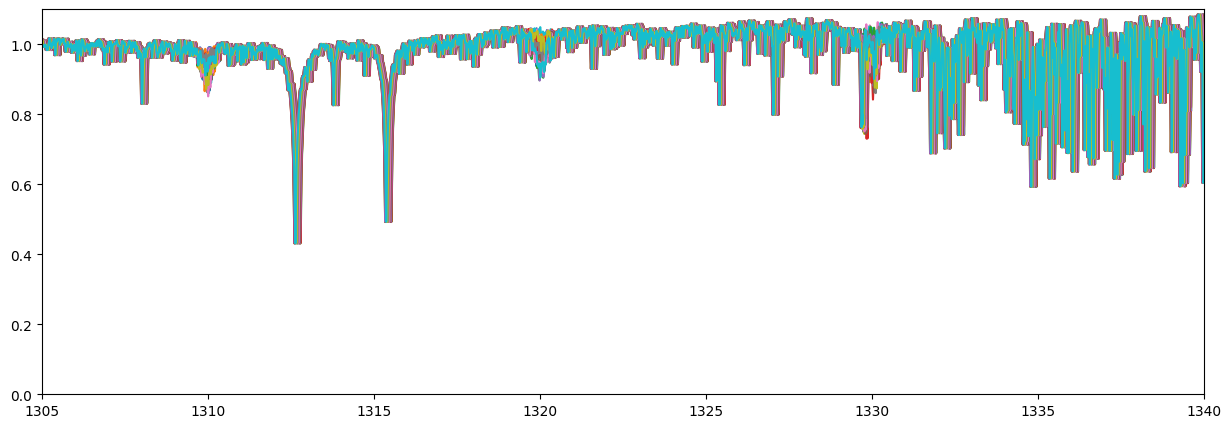

In [9]:
import matplotlib.pylab as plt 

plt.figure(figsize=(15,5))
for i in range(20):
    plt.plot(obs.wgrid, obs.telluric_observations[0,i]/np.median(obs.telluric_observations))
plt.xlim(1305,1340)
plt.ylim(0,1.1)

(0.0, 1.1)

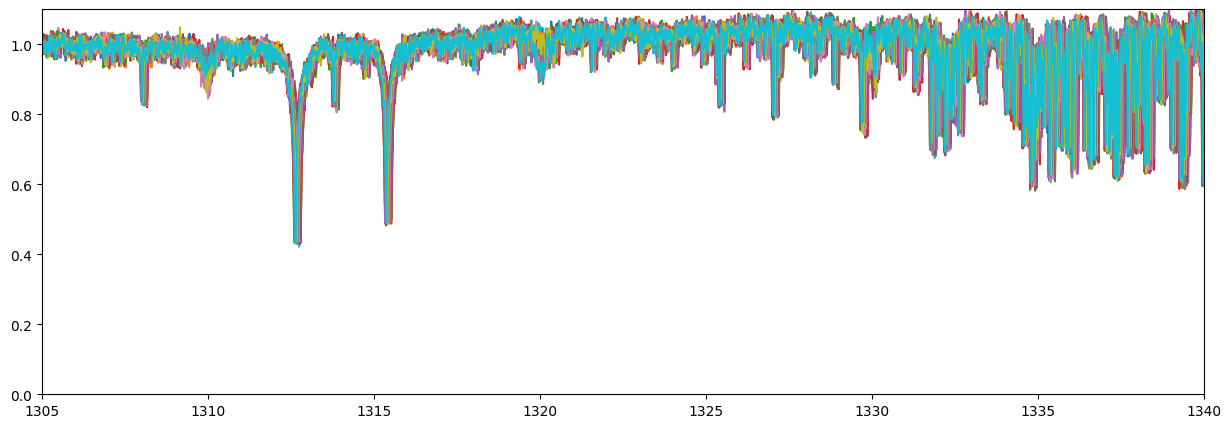

In [10]:
plt.figure(figsize=(15,5))
for i in range(20):
    plt.plot(obs.inst_wgrid, synthetic_spectra[0,i]/np.median(synthetic_spectra))
plt.xlim(1305,1340)
plt.ylim(0,1.1)

In [11]:
obs.shifted_observations.shape

torch.Size([1, 20, 18678])